In [36]:
from spidercat.draw import draw_spanning_forest_solution
from spidercat.spanning_tree import find_min_height_roots, match_forest_leaves_to_marked_edges
from spidercat.utils import load_solution_triplet
from spidercat.circuit_extraction import extract_circuit_rooted

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


{(2, 3), (0, 2), (1, 3)}
{(2, 3): 2, (0, 2): 2, (1, 3): 2}
{2: [(2, 3)], 3: [(2, 3)], 0: [(0, 2), (0, 2)], 1: [(1, 3), (1, 3)]}


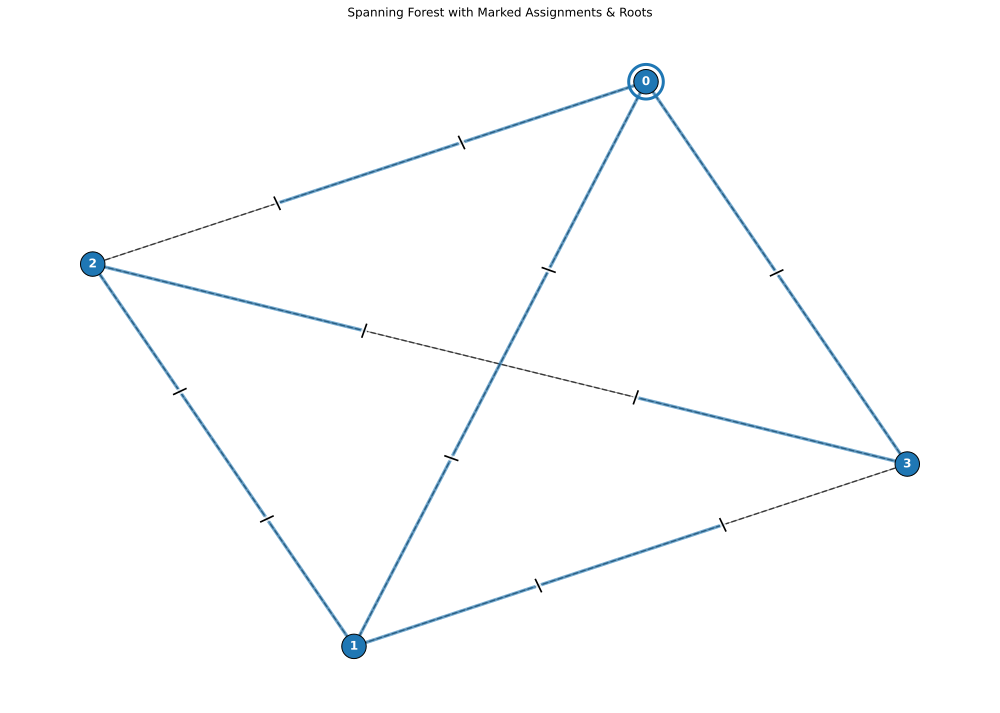

In [37]:
grf, forest, M, matchings = load_solution_triplet(11, 2, 1)
roots = find_min_height_roots(forest)

matchings = match_forest_leaves_to_marked_edges(grf, forest, M)
print(matchings)
roots = find_min_height_roots(forest)
draw_spanning_forest_solution(grf, forest, M, matchings, roots)

=== Starting Clean Extraction ===
  Estimated Data Qubits: 11
  Flags start at: 11
Init Root 0 (Tree 0) -> Q0
    Match Allocation: Node 0 (Internal Node) spawns Q1 for (0, 2)
    Internal Mark (0, 2): Added Q2, CNOT 1 -> 2
    Link (0, 2) (1st visit): Created Flag 11, CNOT 1->11
  Node 0 -> Branch 3 (New Q3)
    Internal Mark (0, 3): Added Q4
    Match Allocation: Node 3 absorbs (2, 3)
    Link (1, 3) (1st visit): Created Flag 12, CNOT 3->12
    Link (2, 3) (1st visit): Created Flag 13, CNOT 3->13
  Node 0 -> Primary 1 (Inherits Q0)
    Internal Mark (0, 1): Added Q5
    Internal Mark (0, 1): Added Q6
    Match Allocation: Node 1 (Internal Node) spawns Q7 for (1, 3)
    Internal Mark (1, 3): Added Q8, CNOT 7 -> 8
    Link (1, 3) (2nd visit): Retrieved Flag 12, CNOT Q7->12
  Node 1 -> Primary 2 (Inherits Q0)
    Internal Mark (1, 2): Added Q9
    Internal Mark (1, 2): Added Q10
    Match Allocation: Node 2 absorbs (2, 3)
    Link (0, 2) (2nd visit): Retrieved Flag 11, CNOT Q0->11
    L

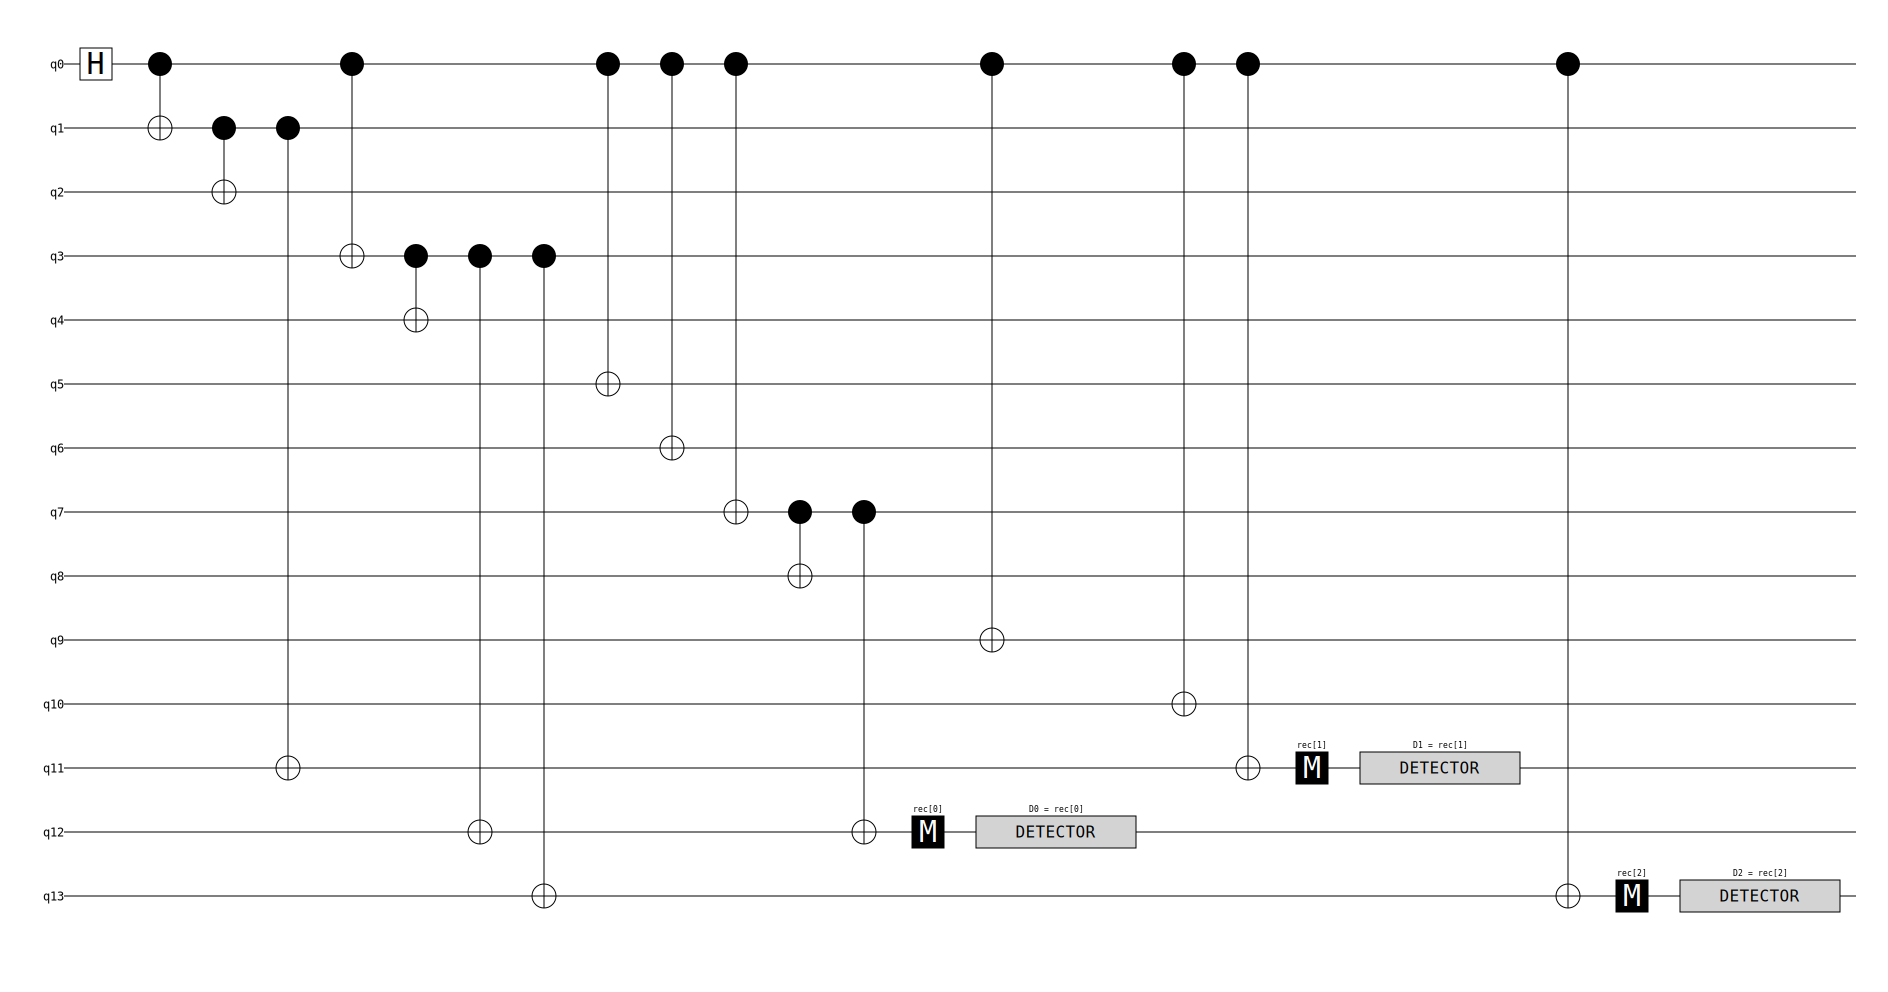

In [38]:
circ = extract_circuit_rooted(grf, forest, roots, M, matchings, verbose=True)
circ.diagram('timeline-svg')